<a href="https://colab.research.google.com/github/larissaorsomarso/mvp-cep-concreto/blob/main/MVP_CEP_Concreto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configurações visuais globais
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

# Carregamento direto do repositório UCI
url = ("https://archive.ics.uci.edu/ml/machine-learning-databases"
       "/concrete/compressive/Concrete_Data.xls")

df_raw = pd.read_excel(url)

# Renomeando colunas para português — facilita a leitura do relatório
df_raw.columns = [
    "cimento",             # kg/m³
    "escoria",             # kg/m³  (escória de alto-forno)
    "cinza_volante",       # kg/m³
    "agua",                # kg/m³
    "superplastificante",  # kg/m³
    "agregado_graudo",     # kg/m³
    "agregado_miudo",      # kg/m³
    "idade",               # dias
    "resistencia"          # MPa — variável alvo contínua
]

print("✔ Dados carregados com sucesso.")
print(f"   Linhas: {df_raw.shape[0]}  |  Colunas: {df_raw.shape[1]}")

✔ Dados carregados com sucesso.
   Linhas: 1030  |  Colunas: 9


In [3]:
# BLOCO 2: INSPEÇÃO INICIAL DOS DADOS


print("=" * 55)
print("INSPEÇÃO INICIAL")
print("=" * 55)

# 2.1 — Primeiras e últimas linhas
print("\n--- Primeiras 5 linhas ---")
print(df_raw.head())

print("\n--- Últimas 5 linhas ---")
print(df_raw.tail())

# 2.2 — Tipos de dados
print("\n--- Tipos de dados e valores não nulos ---")
print(df_raw.info())

# 2.3 — Verificação de valores ausentes
print("\n--- Valores ausentes por coluna ---")
nulos = df_raw.isnull().sum()
print(nulos)
if nulos.sum() == 0:
    print("  → Nenhum valor ausente encontrado.")

# 2.4 — Verificação de duplicatas
n_dup = df_raw.duplicated().sum()
print(f"\n--- Linhas duplicadas: {n_dup} ---")
if n_dup > 0:
    print(df_raw[df_raw.duplicated(keep=False)])

INSPEÇÃO INICIAL

--- Primeiras 5 linhas ---
   cimento  escoria  cinza_volante   agua  superplastificante  \
0    540.0      0.0            0.0  162.0                 2.5   
1    540.0      0.0            0.0  162.0                 2.5   
2    332.5    142.5            0.0  228.0                 0.0   
3    332.5    142.5            0.0  228.0                 0.0   
4    198.6    132.4            0.0  192.0                 0.0   

   agregado_graudo  agregado_miudo  idade  resistencia  
0           1040.0           676.0     28    79.986111  
1           1055.0           676.0     28    61.887366  
2            932.0           594.0    270    40.269535  
3            932.0           594.0    365    41.052780  
4            978.4           825.5    360    44.296075  

--- Últimas 5 linhas ---
      cimento  escoria  cinza_volante   agua  superplastificante  \
1025    276.4    116.0           90.3  179.6                 8.9   
1026    322.2      0.0          115.6  196.0                

In [4]:
# BLOCO 3: ESTATÍSTICAS DESCRITIVAS COMPLETAS

print("=" * 55)
print("ESTATÍSTICAS DESCRITIVAS")
print("=" * 55)

# 3.1 — Tabela completa com medidas além do describe() padrão
desc = df_raw.describe().T  # .T = transposta, mais legível
desc["cv%"] = (desc["std"] / desc["mean"] * 100).round(2)   # coeficiente de variação
desc["mediana"] = df_raw.median()
desc["amplitude"] = desc["max"] - desc["min"]

# Selecionando e ordenando as colunas que importam
desc_final = desc[["count", "mean", "mediana", "std", "cv%",
                    "min", "25%", "75%", "max", "amplitude"]]
desc_final.columns = ["N", "Média", "Mediana", "DP", "CV%",
                       "Mín", "Q1", "Q3", "Máx", "Amplitude"]

print(desc_final.round(2).to_string())

# 3.2 — Foco na variável-chave: resistência
r = df_raw["resistencia"]
print("\n--- Indicadores adicionais: Resistência (MPa) ---")
print(f"  Assimetria (skewness):  {r.skew():.3f}")
print(f"  Curtose:                {r.kurt():.3f}")
print(f"  % acima de 40 MPa:      {(r >= 40).mean()*100:.1f}%")
print(f"  % abaixo de 40 MPa:     {(r < 40).mean()*100:.1f}%")

ESTATÍSTICAS DESCRITIVAS
                         N   Média  Mediana      DP     CV%     Mín      Q1       Q3     Máx  Amplitude
cimento             1030.0  281.17   272.90  104.51   37.17  102.00  192.38   350.00   540.0     438.00
escoria             1030.0   73.90    22.00   86.28  116.76    0.00    0.00   142.95   359.4     359.40
cinza_volante       1030.0   54.19     0.00   64.00  118.10    0.00    0.00   118.27   200.1     200.10
agua                1030.0  181.57   185.00   21.36   11.76  121.75  164.90   192.00   247.0     125.25
superplastificante  1030.0    6.20     6.35    5.97   96.30    0.00    0.00    10.16    32.2      32.20
agregado_graudo     1030.0  972.92   968.00   77.75    7.99  801.00  932.00  1029.40  1145.0     344.00
agregado_miudo      1030.0  773.58   779.51   80.18   10.36  594.00  730.95   824.00   992.6     398.60
idade               1030.0   45.66    28.00   63.17  138.34    1.00    7.00    56.00   365.0     364.00
resistencia         1030.0   35.82    3

MATRIZ DE CORRELAÇÃO

Correlação de cada variável com a RESISTÊNCIA:
  cimento                +0.498  ↑  (moderada)
  superplastificante     +0.366  ↑  (moderada)
  idade                  +0.329  ↑  (moderada)
  escoria                +0.135  ↑  (fraca)
  cinza_volante          -0.106  ↓  (fraca)
  agregado_graudo        -0.165  ↓  (fraca)
  agregado_miudo         -0.167  ↓  (fraca)
  agua                   -0.290  ↓  (fraca)


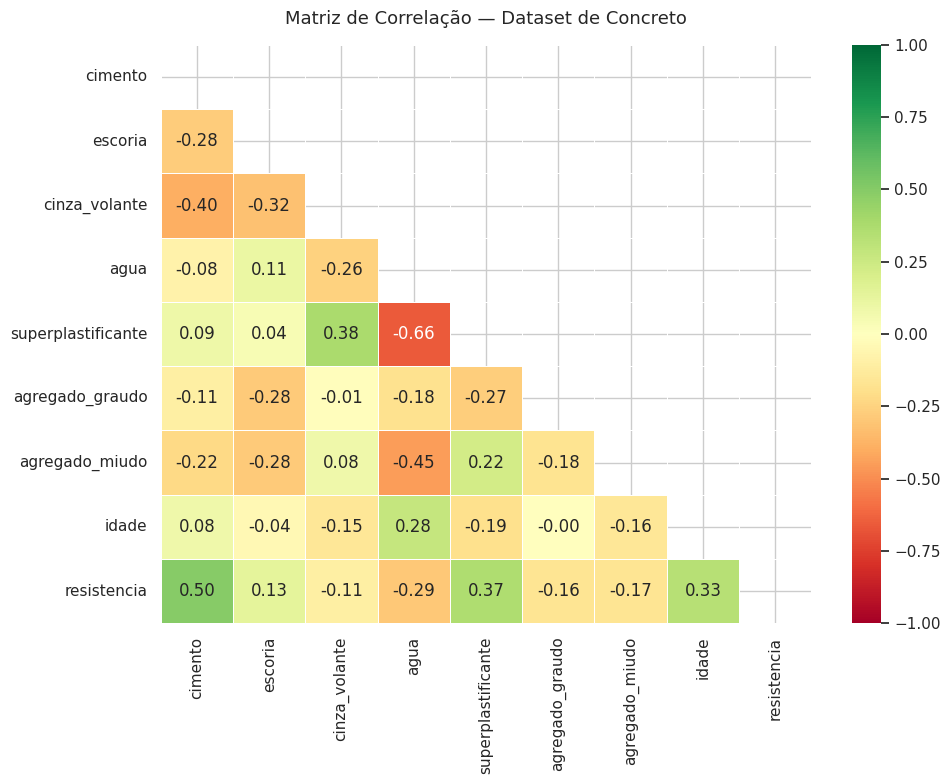

  → Figura salva: correlacoes.png


In [5]:
# BLOCO 4: ANÁLISE DE CORRELAÇÕES

print("=" * 55)
print("MATRIZ DE CORRELAÇÃO")
print("=" * 55)

correlacoes = df_raw.corr(numeric_only=True)

# 4.1 — Exibindo correlações com a resistência, ordenadas
cor_resist = (correlacoes["resistencia"]
              .drop("resistencia")
              .sort_values(ascending=False))

print("\nCorrelação de cada variável com a RESISTÊNCIA:")
for var, val in cor_resist.items():
    sinal = "↑" if val > 0 else "↓"
    forca = "forte" if abs(val) > 0.5 else ("moderada" if abs(val) > 0.3 else "fraca")
    print(f"  {var:<22} {val:+.3f}  {sinal}  ({forca})")

# 4.2 — Heatmap visual
fig, ax = plt.subplots(figsize=(10, 8))

mascara = np.triu(np.ones_like(correlacoes, dtype=bool))  # mostra só metade

sns.heatmap(
    correlacoes,
    mask=mascara,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax
)

ax.set_title("Matriz de Correlação — Dataset de Concreto", pad=15)
plt.tight_layout()
plt.savefig("correlacoes.png", bbox_inches="tight")
plt.show()
print("  → Figura salva: correlacoes.png")

ANÁLISE DE DISTRIBUIÇÃO E NORMALIDADE

Teste de Shapiro-Wilk (H0: distribuição normal):
  Variável                 W-stat    p-valor   Normal?
  ----------------------------------------------------
  cimento                  0.9590     0.0000       Não
  escoria                  0.8124     0.0000       Não
  cinza_volante            0.7620     0.0000       Não
  agua                     0.9804     0.0000       Não
  superplastificante       0.8660     0.0000       Não
  agregado_graudo          0.9825     0.0000       Não
  agregado_miudo           0.9807     0.0000       Não
  idade                    0.5907     0.0000       Não
  resistencia              0.9798     0.0000       Não


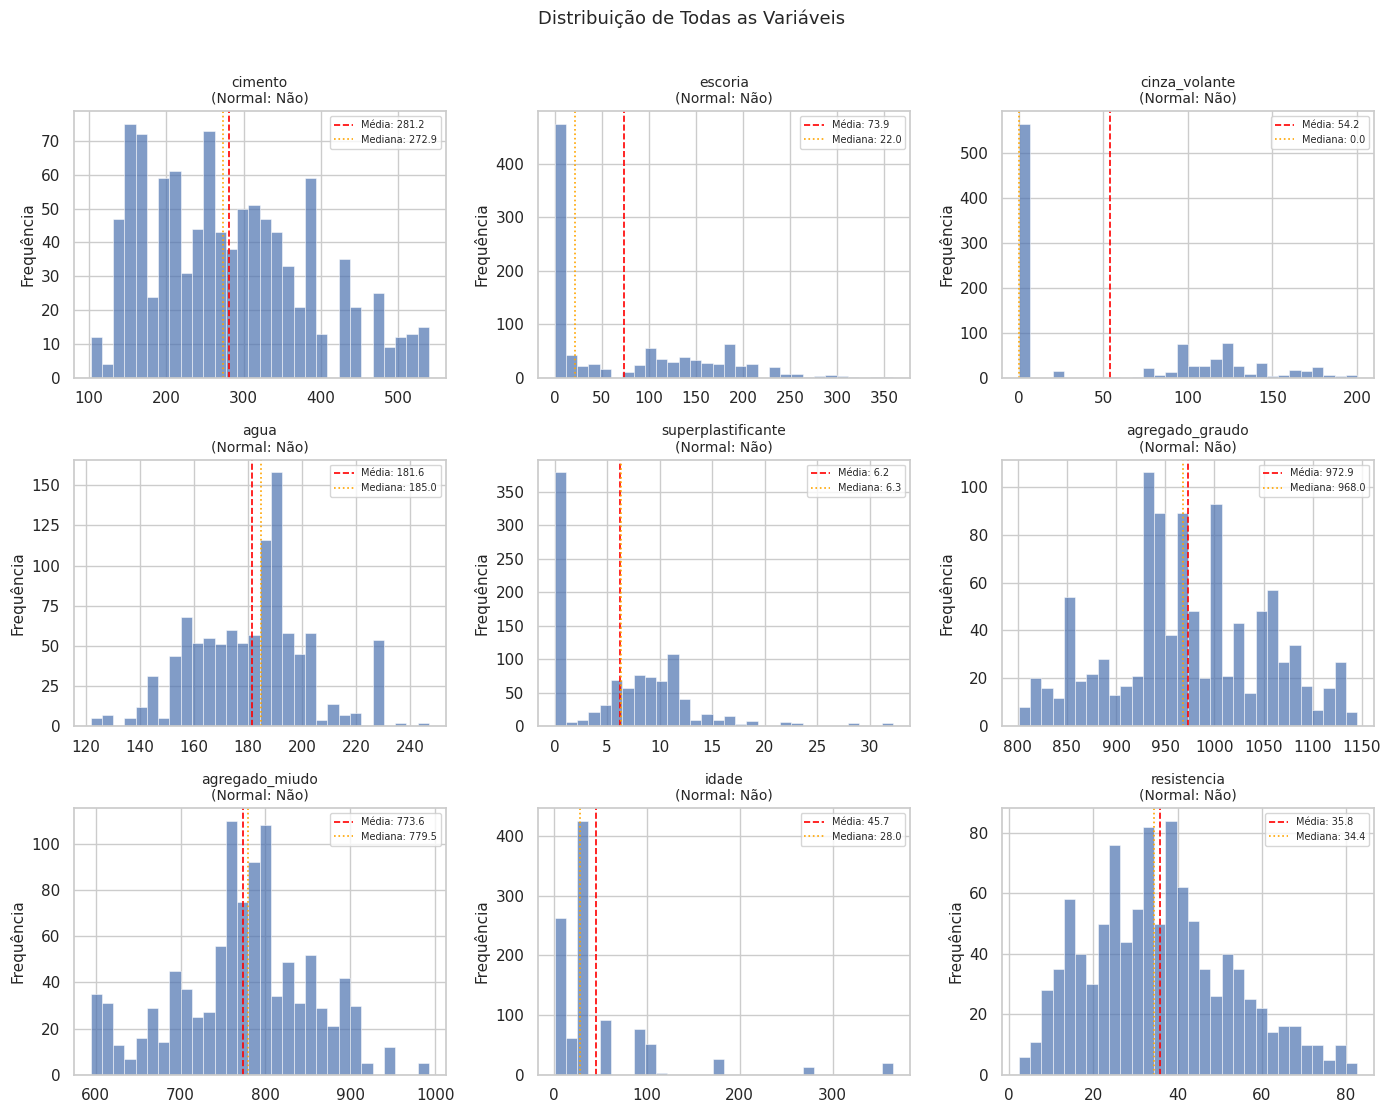

  → Figura salva: distribuicoes.png


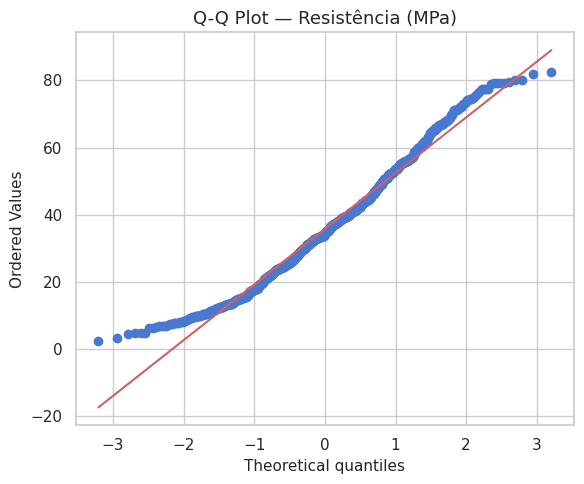

  → Figura salva: qqplot_resistencia.png


In [6]:
# BLOCO 5: DISTRIBUIÇÃO E TESTE DE NORMALIDADE

print("=" * 55)
print("ANÁLISE DE DISTRIBUIÇÃO E NORMALIDADE")
print("=" * 55)

variaveis = df_raw.columns.tolist()

# 5.1 — Teste de Shapiro-Wilk para cada variável
# (usa amostra de 50 por limitação do teste para n > 5000)
print("\nTeste de Shapiro-Wilk (H0: distribuição normal):")
print(f"  {'Variável':<22} {'W-stat':>8}  {'p-valor':>9}  {'Normal?':>8}")
print("  " + "-" * 52)

resultados_normalidade = {}
for col in variaveis:
    amostra = df_raw[col].dropna()
    if len(amostra) > 5000:
        amostra = amostra.sample(5000, random_state=42)
    stat, p = stats.shapiro(amostra)
    normal = "Sim" if p > 0.05 else "Não"
    resultados_normalidade[col] = {"stat": stat, "p": p, "normal": normal}
    print(f"  {col:<22} {stat:>8.4f}  {p:>9.4f}  {normal:>8}")

# 5.2 — Visualização: histogramas + Q-Q plot da resistência
fig, axes = plt.subplots(3, 3, figsize=(14, 11))
axes = axes.flatten()

for i, col in enumerate(variaveis):
    ax = axes[i]
    dados = df_raw[col].dropna()

    ax.hist(dados, bins=30, color="#4C72B0", alpha=0.7,
            edgecolor="white", linewidth=0.5)
    ax.axvline(dados.mean(), color="red",
               linestyle="--", linewidth=1.2, label=f"Média: {dados.mean():.1f}")
    ax.axvline(dados.median(), color="orange",
               linestyle=":", linewidth=1.2, label=f"Mediana: {dados.median():.1f}")

    normal_str = resultados_normalidade[col]["normal"]
    ax.set_title(f"{col}\n(Normal: {normal_str})", fontsize=10)
    ax.legend(fontsize=7)
    ax.set_ylabel("Frequência")

plt.suptitle("Distribuição de Todas as Variáveis", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("distribuicoes.png", bbox_inches="tight")
plt.show()
print("  → Figura salva: distribuicoes.png")

# 5.3 — Q-Q plot específico para resistência (importante para CEP)
fig, ax = plt.subplots(figsize=(6, 5))
stats.probplot(df_raw["resistencia"], dist="norm", plot=ax)
ax.set_title("Q-Q Plot — Resistência (MPa)")
plt.tight_layout()
plt.savefig("qqplot_resistencia.png", bbox_inches="tight")
plt.show()
print("  → Figura salva: qqplot_resistencia.png")

VARIÁVEL ALVO E BALANCEAMENTO

  Limiar adotado: 40 MPa

  Classe                         N        %
  ----------------------------------------
  Comum (< 40 MPa)             651    63.2%
  Alta Res. (≥ 40 MPa)         379    36.8%

  Razão Alta/Comum: 0.58
  ✔ Dataset razoavelmente balanceado.


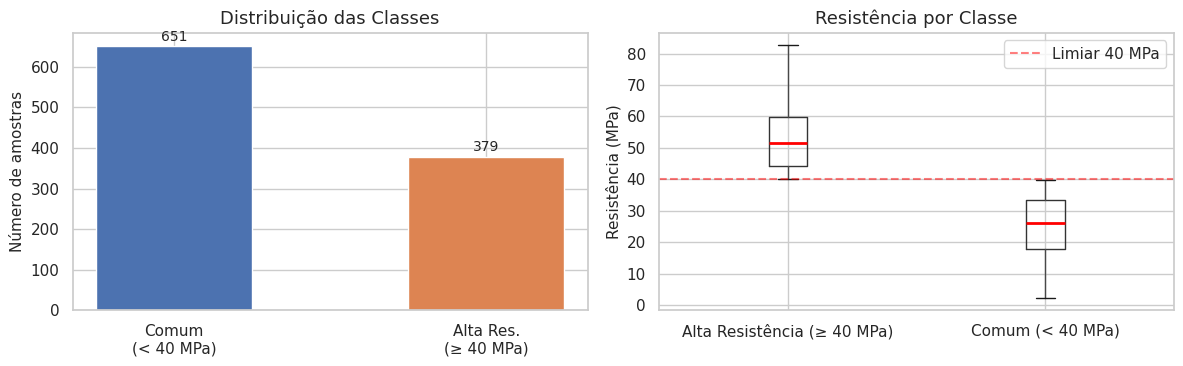

  → Figura salva: balanceamento_classes.png


In [7]:
# BLOCO 6: VARIÁVEL ALVO E BALANCEAMENTO DAS CLASSES

print("=" * 55)
print("VARIÁVEL ALVO E BALANCEAMENTO")
print("=" * 55)

# Criando a variável binária (limiar 40 MPa)
LIMIAR_MPa = 40
df_raw["categoria"] = (df_raw["resistencia"] >= LIMIAR_MPa).astype(int)
df_raw["categoria_label"] = df_raw["categoria"].map(
    {0: "Comum (< 40 MPa)", 1: "Alta Resistência (≥ 40 MPa)"}
)

# Contagem e proporção
contagem = df_raw["categoria"].value_counts().sort_index()
proporcao = df_raw["categoria"].value_counts(normalize=True).sort_index() * 100

print(f"\n  Limiar adotado: {LIMIAR_MPa} MPa")
print(f"\n  {'Classe':<25} {'N':>6}  {'%':>7}")
print("  " + "-" * 40)
for cat, n in contagem.items():
    label = "Comum (< 40 MPa)" if cat == 0 else "Alta Res. (≥ 40 MPa)"
    print(f"  {label:<25} {n:>6}  {proporcao[cat]:>6.1f}%")

razao = contagem[1] / contagem[0]
print(f"\n  Razão Alta/Comum: {razao:.2f}")
if razao < 0.5 or razao > 2.0:
    print("  ⚠ Dataset desbalanceado — considerar SMOTE ou pesos nas Partes 3 e 4.")
else:
    print("  ✔ Dataset razoavelmente balanceado.")

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico de barras
cores = ["#4C72B0", "#DD8452"]
axes[0].bar(["Comum\n(< 40 MPa)", "Alta Res.\n(≥ 40 MPa)"],
            contagem.values, color=cores, edgecolor="white", width=0.5)
axes[0].set_title("Distribuição das Classes")
axes[0].set_ylabel("Número de amostras")
for i, v in enumerate(contagem.values):
    axes[0].text(i, v + 5, str(v), ha="center", va="bottom", fontsize=10)

# Boxplot por categoria
df_raw.boxplot(column="resistencia", by="categoria_label",
               ax=axes[1], grid=True,
               boxprops=dict(color="#333"),
               medianprops=dict(color="red", linewidth=2))
axes[1].set_title("Resistência por Classe")
axes[1].set_xlabel("")
axes[1].set_ylabel("Resistência (MPa)")
axes[1].axhline(LIMIAR_MPa, color="red",
                linestyle="--", alpha=0.5, label=f"Limiar {LIMIAR_MPa} MPa")
axes[1].legend()
plt.suptitle("")
plt.tight_layout()
plt.savefig("balanceamento_classes.png", bbox_inches="tight")
plt.show()
print("  → Figura salva: balanceamento_classes.png")

In [8]:
# BLOCO 7: PREPARAÇÃO DOS DADOS PARA O CEP
# Este bloco entrega os DataFrames prontos para a Parte 2

print("=" * 55)
print("PREPARAÇÃO PARA ANÁLISE CEP")
print("=" * 55)

# 7.1 — Dataset completo limpo (sem duplicatas)
df = df_raw.drop_duplicates().copy()
n_removidos = len(df_raw) - len(df)
print(f"\n  Registros originais:  {len(df_raw)}")
print(f"  Duplicatas removidas: {n_removidos}")
print(f"  Registros finais:     {len(df)}")

# 7.2 — Dataset filtrado por idade (28 dias — padrão ABNT NBR 5739)
df_28 = df[df["idade"] == 28].copy().reset_index(drop=True)
df_28["seq_producao"] = range(1, len(df_28) + 1)  # índice de sequência temporal

print(f"\n  Amostras aos 28 dias: {len(df_28)}")
print(f"  (Estas serão usadas nas Cartas de Controle — Parte 2)")

# 7.3 — Distribuição por idade (para referência)
print("\n  Distribuição de amostras por idade (dias):")
dist_idade = df["idade"].value_counts().sort_index()
for idade, n in dist_idade.items():
    barra = "█" * (n // 5)
    print(f"  {str(idade).rjust(4)} dias: {n:>4} amostras  {barra}")

# 7.4 — Resumo final dos objetos disponíveis
print("\n" + "=" * 55)
print("OBJETOS DISPONÍVEIS PARA AS PRÓXIMAS PARTES:")
print("=" * 55)
print("  df      → Dataset completo limpo (todas as idades)")
print("  df_28   → Somente ensaios de 28 dias (para CEP)")
print(f"            Shape: {df_28.shape}")
print("  LIMIAR_MPa = 40  (limiar para classificação binária)")

PREPARAÇÃO PARA ANÁLISE CEP

  Registros originais:  1030
  Duplicatas removidas: 25
  Registros finais:     1005

  Amostras aos 28 dias: 419
  (Estas serão usadas nas Cartas de Controle — Parte 2)

  Distribuição de amostras por idade (dias):
     1 dias:    2 amostras  
     3 dias:  129 amostras  █████████████████████████
     7 dias:  122 amostras  ████████████████████████
    14 dias:   62 amostras  ████████████
    28 dias:  419 amostras  ███████████████████████████████████████████████████████████████████████████████████
    56 dias:   86 amostras  █████████████████
    90 dias:   54 amostras  ██████████
    91 dias:   17 amostras  ███
   100 dias:   52 amostras  ██████████
   120 dias:    3 amostras  
   180 dias:   26 amostras  █████
   270 dias:   13 amostras  ██
   360 dias:    6 amostras  █
   365 dias:   14 amostras  ██

OBJETOS DISPONÍVEIS PARA AS PRÓXIMAS PARTES:
  df      → Dataset completo limpo (todas as idades)
  df_28   → Somente ensaios de 28 dias (para CEP)
      